# Práctica Final TI24 - Modelo Comparativo: Regresión Logística
## Tema: Bagging - Random Forests
### Dataset: Loan Default Prediction

### Objetivo

Comparar el modelo principal **Random Forest** con **Regresión Logística** usando las mismas métricas: accuracy, F1-score, matriz de confusión y curva ROC.


## 2. Importación de librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)


## 3. Carga y preprocesamiento del dataset

Se aplica el mismo preprocesamiento que en `02_preprocessing.ipynb` y `03_model_main.ipynb` para garantizar una comparación justa entre modelos.


In [4]:
url = "https://raw.githubusercontent.com/soledadaldunate/repositorio-TI24-Aldunate/main/data/raw/Loan_default.csv"
df = pd.read_csv(url)
df = df.drop(columns=["LoanID"])

# Encoding de variables categóricas
variables_categoricas = ["Education", "EmploymentType", "MaritalStatus",
                         "HasMortgage", "HasDependents", "LoanPurpose", "HasCoSigner"]
for col in variables_categoricas:
    df[col] = LabelEncoder().fit_transform(df[col])

# Split
X = df.drop(columns=["Default"])
y = df["Default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
variables_numericas = ["Age", "Income", "LoanAmount", "CreditScore",
                       "MonthsEmployed", "NumCreditLines", "InterestRate",
                       "LoanTerm", "DTIRatio"]
scaler = StandardScaler()
X_train[variables_numericas] = scaler.fit_transform(X_train[variables_numericas])
X_test[variables_numericas] = scaler.transform(X_test[variables_numericas])

print("Dataset listo. X_train:", X_train.shape, "| X_test:", X_test.shape)


Dataset listo. X_train: (204277, 16) | X_test: (51070, 16)


## 4. Entrenamiento de ambos modelos

In [5]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Random Forest entrenado.")

# Regresión Logística
# class_weight='balanced' para compensar el desbalance igual que en RF.
# max_iter=1000 garantiza convergencia con el tamaño del dataset (>200k registros).
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
log_model.fit(X_train, y_train)
print("Regresión Logística entrenada.")


Random Forest entrenado.
Regresión Logística entrenada.


## 5. Predicciones de ambos modelos

In [6]:
# Random Forest
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Regresión Logística
y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:, 1]


## 6. Comparación de métricas

In [7]:
resultados = pd.DataFrame({
    "Modelo": ["Random Forest", "Regresión Logística"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_log)
    ],
    "F1-score (Default)": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_log)
    ],
    "AUC": [
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_log)
    ]
})

print(resultados.round(4).to_string(index=False))


             Modelo  Accuracy  F1-score (Default)    AUC
      Random Forest    0.7736              0.3597 0.7507
Regresión Logística    0.6740              0.3337 0.7498


## 7. Reportes de clasificación completos

In [8]:
print("="*55)
print("RANDOM FOREST")
print("="*55)
print(classification_report(y_test, y_pred_rf, target_names=["No Default (0)", "Default (1)"]))

print("="*55)
print("REGRESIÓN LOGÍSTICA")
print("="*55)
print(classification_report(y_test, y_pred_log, target_names=["No Default (0)", "Default (1)"]))


RANDOM FOREST
                precision    recall  f1-score   support

No Default (0)       0.93      0.80      0.86     45139
   Default (1)       0.27      0.55      0.36      5931

      accuracy                           0.77     51070
     macro avg       0.60      0.68      0.61     51070
  weighted avg       0.85      0.77      0.80     51070

REGRESIÓN LOGÍSTICA
                precision    recall  f1-score   support

No Default (0)       0.94      0.67      0.78     45139
   Default (1)       0.22      0.70      0.33      5931

      accuracy                           0.67     51070
     macro avg       0.58      0.69      0.56     51070
  weighted avg       0.86      0.67      0.73     51070



## 8. Matrices de confusión comparadas

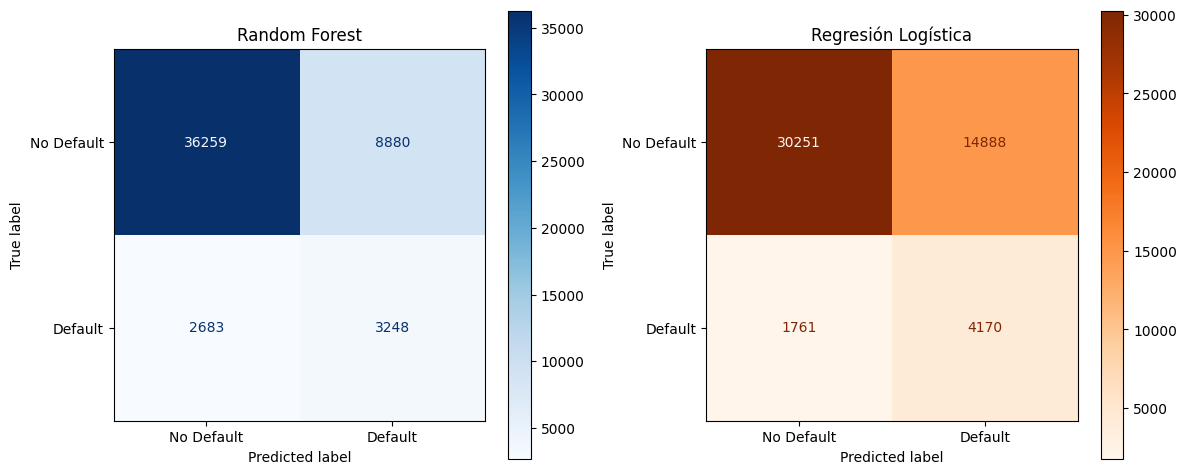

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_rf),
    display_labels=["No Default", "Default"]
).plot(ax=axes[0], cmap="Blues", values_format="d")
axes[0].set_title("Random Forest")

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_log),
    display_labels=["No Default", "Default"]
).plot(ax=axes[1], cmap="Oranges", values_format="d")
axes[1].set_title("Regresión Logística")

plt.tight_layout()
plt.show()


## 9. Curvas ROC comparadas

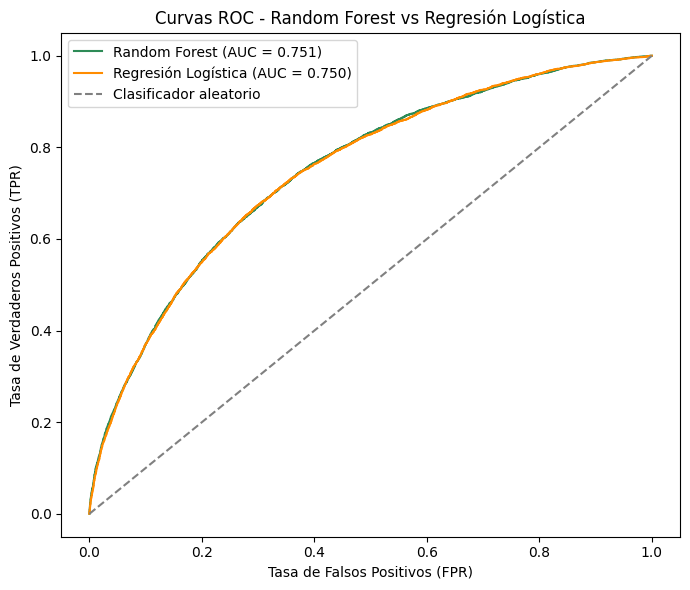

In [10]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
auc_log = roc_auc_score(y_test, y_proba_log)

plt.figure(figsize=(7, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})", color="seagreen")
plt.plot(fpr_log, tpr_log, label=f"Regresión Logística (AUC = {auc_log:.3f})", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curvas ROC - Random Forest vs Regresión Logística")
plt.legend()
plt.tight_layout()
plt.show()
